# RNN Binary Sequence Signal Classifier

Recurrent Neural Networks (RNNs) process sequential input arrays step-by-step, maintaining recurrent hidden states to pass historical context forward. In telemetry, RNN classifiers predict category classes of temporal signals (such as normal pulses vs. anomalous waveforms). This notebook trains an RNN classifier in PyTorch to identify frequency signals and visualizes binary cross-entropy loss decay.



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic signal sequences (600 sequences, 20 steps, 2 features)
np.random.seed(220)
n_signals = 600
seq_len = 20
feature_dim = 2

# Base timeline axis
t_axis = np.linspace(0, 4 * np.pi, seq_len)

X_data, y_data = [], []
for _ in range(n_signals):
    label = np.random.randint(0, 2)
    # Signal wave changes depending on label: Class 1 has higher frequency
    freq_mult = 2.0 if label == 1 else 0.8
    noise = np.random.normal(0, 0.25, (seq_len, feature_dim))
    
    # Generate 2D signals: sine and cosine curves
    sig_1 = np.sin(t_axis * freq_mult)
    sig_2 = np.cos(t_axis * freq_mult)
    sequence = np.column_stack((sig_1, sig_2)) + noise
    
    X_data.append(sequence)
    y_data.append(label)

X_tensor = torch.FloatTensor(np.array(X_data)) # [600, 20, 2]
y_tensor = torch.FloatTensor(np.array(y_data)) # [600]

print("Input Signals Tensor Shape:", X_tensor.shape)
print("Binary Labels Tensor Shape:", y_tensor.shape)



Input Signals Tensor Shape: torch.Size([600, 20, 2])
Binary Labels Tensor Shape: torch.Size([600])


## RNN Classifier Architecture

We implement the Recurrent Neural Network in PyTorch:
1. **RNN Layer**: Recurrent cell (hidden dimension = 16) processing sequential inputs.
2. **Linear Head**: Decodes the final hidden step vector.
3. **Sigmoid Output**: Computes probability score bounds.



In [2]:
class SequenceRNN(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=16):
        super(SequenceRNN, self).__init__()
        self.rnn = nn.RNN(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        
    def forward(self, x):
        # rnn_out shape: [batch, seq_len, hidden_dim]
        # hidden shape: [1, batch, hidden_dim]
        rnn_out, hidden = self.rnn(x)
        # Select the final step output vector
        final_step = rnn_out[:, -1, :]
        out = torch.sigmoid(self.fc(final_step)).squeeze(1)
        return out

model = SequenceRNN(input_dim=feature_dim, hidden_dim=16)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)



## RNN Training loop

We train the recurrent network for 120 epochs, monitoring binary cross-entropy (BCE) loss.



In [3]:
epochs = 120
losses = []

print("Training Sequence RNN Classifier...")
for epoch in range(1, epochs + 1):
    model.train()
    predictions = model(X_tensor)
    loss = criterion(predictions, y_tensor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}/{epochs} | BCE Classification Loss: {loss.item():.4f}")



Training Sequence RNN Classifier...
Epoch  20/120 | BCE Classification Loss: 0.0920
Epoch  40/120 | BCE Classification Loss: 0.0065
Epoch  60/120 | BCE Classification Loss: 0.0030
Epoch  80/120 | BCE Classification Loss: 0.0022
Epoch 100/120 | BCE Classification Loss: 0.0017
Epoch 120/120 | BCE Classification Loss: 0.0014


## Classification Loss Decay Plot

We chart the BCE classification loss values over training iterations using Matplotlib.



<cell>:9: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



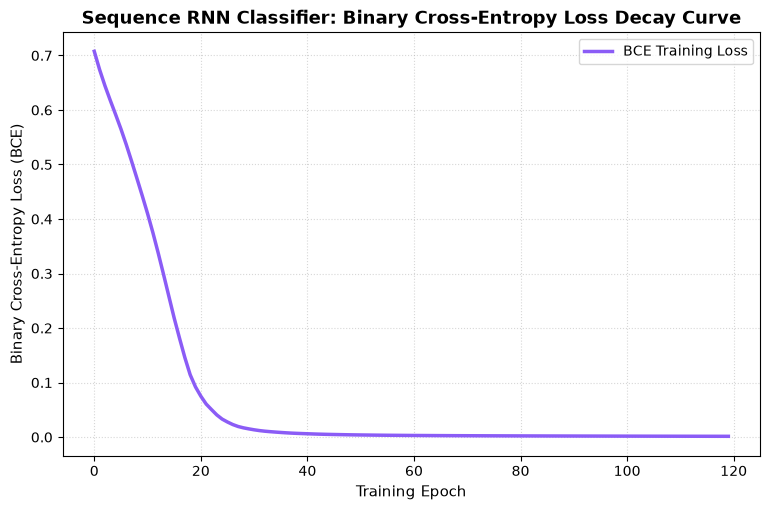

In [4]:
plt.figure(figsize=(9, 5.5))
plt.plot(losses, color='#8B5CF6', linewidth=2.5, label='BCE Training Loss')

plt.title('Sequence RNN Classifier: Binary Cross-Entropy Loss Decay Curve', fontsize=13, fontweight='bold')
plt.xlabel('Training Epoch', fontsize=11)
plt.ylabel('Binary Cross-Entropy Loss (BCE)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()
plt.show()
